In [37]:
from PIL import Image
import numpy as np
from skimage.color import rgb2lab


In [3]:
image = Image.open('Dataset/zoo.jpg').convert('RGB')

image_np = np.array(image).astype(np.float32)/255

lab_image = rgb2lab(image_np)

for i in range(3):
    print(f'Channel {i} has min: {lab_image[:,:,i].min():.2f} and max: {lab_image[:,:,i].max():.2f}')

    if i == 0:
        lab_image[:,:,i] = (lab_image[:,:, i] - 50) / 50
    else:
        lab_image[:,:,i] = lab_image[:,:, i] / 110
    
    print(f'Channel {i} has min: {lab_image[:,:,i].min():.2f} and max: {lab_image[:,:,i].max():.2f}')

Channel 0 has min: 0.20 and max: 96.90
Channel 0 has min: -1.00 and max: 0.94
Channel 1 has min: -54.50 and max: 63.48
Channel 1 has min: -0.50 and max: 0.58
Channel 2 has min: -7.23 and max: 78.45
Channel 2 has min: -0.07 and max: 0.71


# Why Lab color space instead of RGB?

If we predict RGB directly, the network has to output 3 correlated channels (Red, Green, Blue) from a single grayscale input — small errors in each channel compound, often producing muddy or desaturated results.
Lab color space separates lightness from color:

*   L (Lightness) — essentially is our grayscale input, values 0–100
*   a (green ↔ red) and b (blue ↔ yellow) — the actual color information

By converting training images to Lab, the task becomes: given L, predict a and b. The network only needs to learn 2 output channels instead of 3, and since L is fixed (it's literally the input), the model can never mess up brightness — it only has to get color right. This tends to produce cleaner, more accurate colorization than predicting RGB directly.

------

# Building the PyTorch Dataset 

In [38]:
from torch.utils.data import Dataset
import torch

In [39]:
class ColorizationDataset(Dataset):

    def __init__(self, image_paths):
        super().__init__()
        self.image_paths = image_paths # e.g. ['zoo.jpg', 'lion.jpg', 'tiger.jpg']

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        image = image.resize((256,256))

        image_np = np.array(image).astype(np.float32) / 255

        lab_img = rgb2lab(image_np)

        for i in range(3):
            if i == 0:
                lab_img[:,:,i] = (lab_img[:,:, i] - 50) / 50
            else:
                lab_img[:,:,i] = lab_img[:,:, i] / 110
        
        L = lab_img[:,:, 0]
        ab = lab_img[:,:, 1:]
        
        L = torch.tensor(L).unsqueeze(0) # (H, W) -> (1, H, W)
    
        ab = np.transpose(ab, (2,0,1))
        ab = torch.tensor(ab)
    
        return L, ab
        

## Test Time

In [40]:
import glob

image_paths = glob.glob('./Dataset/*.jpg')
print(f'image paths: {image_paths}')

dataset = ColorizationDataset(image_paths)
print(f'Dataset size: {len(dataset)}')

L,ab = dataset[0]

print(f'L shape: {L.shape}, dtype: {L.dtype}')
print(f'ab shape: {ab.shape}, dtype: {ab.dtype}')

image paths: ['./Dataset/image_1502.jpg', './Dataset/image_811.jpg', './Dataset/image_1264.jpg', './Dataset/image_1270.jpg', './Dataset/image_2779.jpg', './Dataset/image_805.jpg', './Dataset/image_1516.jpg', './Dataset/image_2037.jpg', './Dataset/image_1258.jpg', './Dataset/image_2989.jpg', './Dataset/image_193.jpg', './Dataset/image_2751.jpg', './Dataset/image_187.jpg', './Dataset/image_2745.jpg', './Dataset/image_2023.jpg', './Dataset/image_839.jpg', './Dataset/image_2976.jpg', './Dataset/image_178.jpg', './Dataset/image_2962.jpg', './Dataset/image_636.jpg', './Dataset/image_150.jpg', './Dataset/image_2792.jpg', './Dataset/image_144.jpg', './Dataset/image_2786.jpg', './Dataset/image_622.jpg', './Dataset/image_1066.jpg', './Dataset/image_3117.jpg', './Dataset/image_2209.jpg', './Dataset/image_1700.jpg', './Dataset/image_15.jpg', './Dataset/image_1714.jpg', './Dataset/image_3103.jpg', './Dataset/image_1072.jpg', './Dataset/image_2553.jpg', './Dataset/image_391.jpg', './Dataset/image_29

everything looks fine time to move on and collect images

--------------

# API Settings

In [41]:
import requests 
import os
from dotenv import load_dotenv

load_dotenv()
API = os.environ.get('PEXELS_API_KEY')

print(API is not None)

True


In [55]:
url = 'https://api.pexels.com/v1/search'

headers = {"Authorization": API}
queries = ['landscape', 'coffee', 'animals', 'art gallery', 'city', 'people', 'forest', 
           'beach', 'mountains', 'sunset', 'flowers', 'portrait', 'family', 'kitchen',
           'library', 'fruit', 'pets', 'bird', 'cat', 'dog', "rainbow", "colorful architecture", 
           "street art", "graffiti", "flower garden", "tropical flowers", "autumn leaves", 
           "festival", "fireworks", "carnival", "candy", "balloons", "neon lights",
           "tropical fish", "parrot", "stained glass", "spice market", "kites", 
           "textile fabric", "coral reef"] 

img_urls = []
i = 0

for query in queries:
    i+= 1
    params = {
        'query' : query,
        'per_page' : 80 # for this search term, give me 50 photos back. Max value: 80
    }

    response = requests.get(url, headers=headers, params=params)
    print(f"{query}: {response.status_code}", end = ' ')

    if i % 10 == 0:
        print('')
    
    data = response.json()
    photos = data['photos']

    for photo in photos:
        image_url = photo['src']['large']
        img_urls.append(image_url)


landscape: 200 coffee: 200 animals: 200 art gallery: 200 city: 200 people: 200 forest: 200 beach: 200 mountains: 200 sunset: 200 
flowers: 200 portrait: 200 family: 200 kitchen: 200 library: 200 fruit: 200 pets: 200 bird: 200 cat: 200 dog: 200 
rainbow: 200 colorful architecture: 200 street art: 200 graffiti: 200 flower garden: 200 tropical flowers: 200 autumn leaves: 200 festival: 200 fireworks: 200 carnival: 200 
candy: 200 balloons: 200 neon lights: 200 tropical fish: 200 parrot: 200 stained glass: 200 spice market: 200 kites: 200 textile fabric: 200 coral reef: 200 


In [56]:
from tqdm import tqdm

for i, img_url in enumerate(tqdm(img_urls)):
    response = requests.get(img_url)

    with open(f'./Dataset/image_{i}.jpg', 'wb') as f:
        f.write(response.content)

100%|██████████| 3198/3198 [14:57<00:00,  3.56it/s]


In [42]:
import shutil


dataset_dir = './Dataset'
bad_dir = './Dataset_bad'
os.makedirs(bad_dir, exist_ok=True)

bad_files = []

for filename in os.listdir(dataset_dir):
    filepath = os.path.join(dataset_dir, filename)
    try:
        img = Image.open(filepath)
        img.verify()
    except Exception as e:
        bad_files.append(filename)
        shutil.move(filepath, os.path.join(bad_dir, filename))
        print(f"Moved bad file: {filename} — {e}")

print(f"\nMoved {len(bad_files)} bad files to {bad_dir}")
print(f"Remaining good files: {len(os.listdir(dataset_dir))}")

shutil.rmtree(bad_dir)  # permanently deletes the whole Dataset_bad folder


Moved 0 bad files to ./Dataset_bad
Remaining good files: 3197


In [43]:
image_paths = glob.glob('./Dataset/*.jpg')

dataset = ColorizationDataset(image_paths)

-----

# U-Net Structure 

In [8]:
import torch
import torch.nn as nn

def conv_block(in_channels, out_channels):

    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size= 3, padding= 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),
        nn.Conv2d(out_channels, out_channels, kernel_size= 3, padding= 1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace= True)
    )

In [10]:
block = conv_block(1, 64)
dummy_input = torch.randn(1, 1, 256, 256)
output = block(dummy_input)

print(output.shape)

torch.Size([1, 64, 256, 256])


## Downsampling Step

In [12]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = conv_block(in_channels, out_channels)
    
    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)

        return x

In [13]:
down = Down(64, 128)
dummy = torch.randn(1, 64, 256, 256)
out = down(dummy)
print(out.shape)

torch.Size([1, 128, 128, 128])


## Upsampling step

In [14]:
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size= 2, stride= 2)
        # output_size = (input_size - 1) * stride + kernel_size

        self.conv = conv_block(in_channels, out_channels)
        # in_channels here = concatenated size
    
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.concat([skip, x], dim = 1) # dim1 = channel dimension, (batch, channel, width, height)
        x = self.conv(x)
    
        return x 

In [15]:
up = Up(256, 128)
dummy_x = torch.randn(1, 256, 32, 32)
dummy_skip = torch.randn(1, 128, 64, 64)

out = up(dummy_x, dummy_skip)
print(out.shape)

torch.Size([1, 128, 64, 64])


-------

# ColorizationUNet:

In [ ]:
class ColorizationUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.in_conv = conv_block(1, 32)
        
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        self.up4 = Up(64, 32)

        self.out_conv = nn.Conv2d(32, 2, kernel_size= 1)

    
    def forward(self, x):
        skips = []

        x = self.in_conv(x)
        skips.append(x)

        x = self.down1(x)
        skips.append(x)

        x = self.down2(x)
        skips.append(x)

        x = self.down3(x)
        skips.append(x)

        x = self.down4(x)

        ########

        x = self.up1(x, skips[-1])
        x = self.up2(x, skips[-2])
        x = self.up3(x, skips[-3])
        x = self.up4(x, skips[-4])

        ########

        x = self.out_conv(x)
        x = torch.tanh(x)

        return x

In [17]:
model = ColorizationUNet()
dummy = torch.randn(1, 1, 256, 256)
out = model(dummy)

print(out.shape)

torch.Size([1, 2, 256, 256])


------

# Loss function & training loop

In [33]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

device

device(type='mps')

In [36]:
from torch.utils.data import DataLoader, random_split

image_paths = glob.glob('./Dataset/*.jpg')
dataset = ColorizationDataset(image_paths)

BATCH_SIZE = 8

val_size = int(len(dataset) * 0.1)
train_size = len(dataset) - val_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size= BATCH_SIZE, shuffle= True)
val_loader = DataLoader(val_set, batch_size= BATCH_SIZE, shuffle= False)

model = ColorizationUNet()
model = model.to(device)
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr = 2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode = 'min', factor = 0.5, patience= 10
)

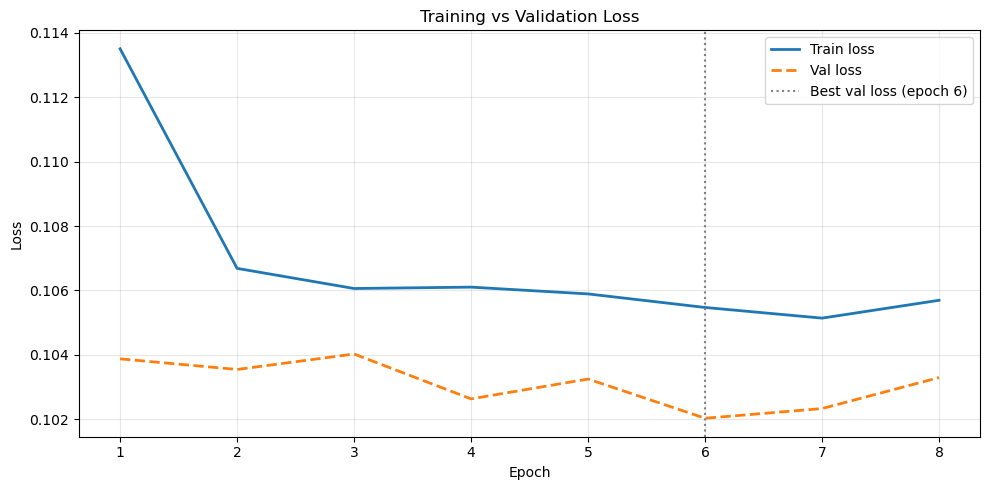

KeyboardInterrupt: 

In [ ]:
from myLibrary import plot_losses, show_predictions

EPOCH = 500
train_losses = []
val_losses = []


for epoch in range(EPOCH):
    model.train()
    total_loss = 0
    val_total_loss = 0

    for L_batch, ab_batch in train_loader:

        L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

        optimizer.zero_grad()
        pred = model(L_batch)

        loss = criterion(ab_batch, pred)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()



    model.eval()
    with torch.no_grad():
        for L_batch, ab_batch in val_loader:

            L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

            pred = model(L_batch)
            loss = criterion(pred, ab_batch)

            val_total_loss += loss.item()

    scheduler.step(val_total_loss/len(val_loader))

    train_losses.append(total_loss/ len(train_loader))
    val_losses.append(val_total_loss / len(val_loader))

    plot_losses(train_losses, val_losses)

